# E-commerce Purchase Intent — Logistic Regression
Predict whether a website session results in a purchase.


In [1]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
df = pd.read_csv("data.csv")
df.head()


,pages_viewed,session_minutes,products_viewed,cart_additions,discount_seen,previous_orders,target
0,27,24.79,3,5,3,5,0
1,54,13.29,2,5,2,5,1
2,45,2.00,5,2,2,1,1
3,50,50.66,5,6,3,3,0
4,34,43.77,2,3,3,1,1


## 1. Data Inspection and Quality Checks


In [2]:
print(df.shape)
display(df.describe())
print('Missing values:\n', df.isna().sum())
print('Duplicates:', df.duplicated().sum())
print('Class balance:\n', df['target'].value_counts())


(1000, 7)


,pages_viewed,session_minutes,products_viewed,cart_additions,discount_seen,previous_orders,target
count,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,40.79200,36.405290,2.922000,2.94100,2.913000,3.024000,0.50000
std,13.90403,18.669218,1.735202,1.71536,1.684716,1.733906,0.50025
min,18.00000,2.000000,0.000000,0.00000,0.000000,0.000000,0.00000
25%,29.00000,23.030000,2.000000,2.00000,2.000000,2.000000,0.00000
50%,40.00000,36.705000,3.000000,3.00000,3.000000,3.000000,0.50000
75%,53.00000,49.607500,4.000000,4.00000,4.000000,4.000000,1.00000
max,65.00000,99.350000,10.000000,10.00000,9.000000,9.000000,1.00000


Missing values:
 pages_viewed       0
session_minutes    0
products_viewed    0
cart_additions     0
discount_seen      0
previous_orders    0
target             0
dtype: int64
Duplicates: 0
Class balance:
 target
0    500
1    500
Name: count, dtype: int64


## 2. Train/Test Split and Preprocessing
An 80/20 stratified split preserves the balanced target distribution. Scaling is inside the pipeline so it is fitted only on training data.


In [3]:
features = ['pages_viewed', 'session_minutes', 'products_viewed', 'cart_additions', 'discount_seen', 'previous_orders']
X, y = df[features], df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
model = Pipeline([('scaler', StandardScaler()), ('logistic_regression', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42))])
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['pages_viewed','session_minutes','products_viewed','cart_additions', 'discount_seen','previous_orders']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 3. Evaluation


In [4]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
results = {
 'Accuracy': accuracy_score(y_test,y_pred),
 'Precision': precision_score(y_test,y_pred),
 'Recall': recall_score(y_test,y_pred),
 'F1-score': f1_score(y_test,y_pred),
 'ROC-AUC': roc_auc_score(y_test,y_prob)
}
pd.Series(results)


Accuracy     0.730000
Precision    0.739583
Recall       0.710000
F1-score     0.724490
ROC-AUC      0.800400
dtype: float64

[[75 25]
 [29 71]]


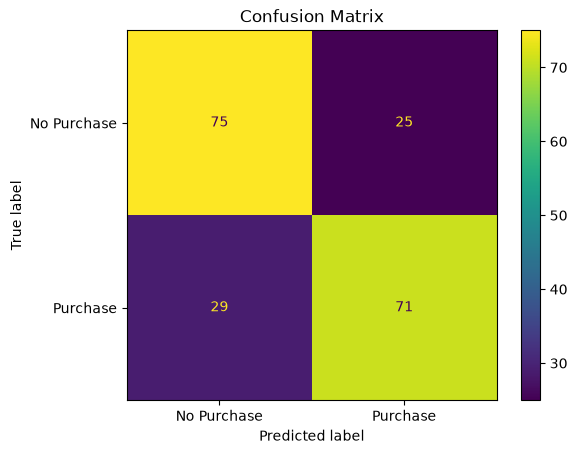

In [5]:
cm = confusion_matrix(y_test,y_pred)
print(cm)
ConfusionMatrixDisplay(cm, display_labels=['No Purchase','Purchase']).plot(values_format='d')
plt.title('Confusion Matrix')
plt.show()


## 4. Coefficient Interpretation
The predictors are standardized, so coefficient magnitudes are more directly comparable. Positive values increase the log-odds of purchase; negative values decrease them.


In [6]:
lr = model.named_steps['logistic_regression']
coef = pd.DataFrame({'feature':features,'coefficient':lr.coef_[0]})
coef['odds_ratio_per_1_SD'] = np.exp(coef['coefficient'])
coef.reindex(coef.coefficient.abs().sort_values(ascending=False).index)


,feature,coefficient,odds_ratio_per_1_SD
4,discount_seen,0.652436,1.920212
0,pages_viewed,0.636743,1.890314
2,products_viewed,0.612051,1.844209
5,previous_orders,-0.394170,0.674239
3,cart_additions,-0.341414,0.710765
1,session_minutes,-0.336669,0.714145


## 5. Conclusion
The model provides a reproducible baseline for purchase-intent prediction. For deployment, threshold selection should reflect the relative business cost of false positives versus false negatives, and performance should be validated with cross-validation and external/temporal data.
